# Soil data standardization and harmonization


We use **[LimoSoDa](https://doi.org/10.1016/j.geoderma.2025.117337)**, a collection of open-source farm-level soil datasets, as an example to demonstrate how our soil data harmonization workflow operates, including both **standardization** and **harmonization** steps.

In this example, we work with two LimoSoDa subsets:

- **NSW.52** (Australia)
- **SC.50** (Brazil)  

This covers three soil properties:
- **Soil Organic Carbon (soc)**
- **pH measured in water (ph.h2o)**
- **Clay content** (mass percentage of particles < 2 µm)


## Standardization

This step collects, standardizes, and unifies soil datasets from multiple formats (JSON, SHP, Excel, CSV, DBF).  
For each data source, a notebook named **`{dataset_id}_standardize.ipynb`** performs the full standardization pipeline.  
Metadata required for the later harmonization step is manually added in **`{dataset_id}_{subset_id}_meta.json`**.

---

### Extracting Metadata into a Standard JSON File  

Soil property metadata often appears in inconsistent formats and may contain varying levels of detail.  
To standardize and automate the workflow, we define a set of metadata fields of interest and manually extract them into a JSON file. These metadata is required for downstream harmonization steps, including:


| Field        | Description |
|--------------|-------------|
| **dataset_id** | Project or data source name (e.g., `LUCAS`). |
| **subset_id**  | Subset of the dataset (e.g., `LUCAS 2009`). |
| **site_id**    | Identifier for individual measurements within the dataset. |
| **country**    | Country where the data was collected. |
| **lat / lon**  | Sample location coordinates (WGS84). |
| **time**       | Sampling time. |
| **hzn_dep** / **hzn_top & hzn_btm** | Reported soil horizon depth (single value or top/bottom). |
| **lc_survey**  | Land cover information collected along with soil samples. |

Apart from the general ones above, there are also metadata for soil property measurements — specifically **units** and **measurement methods** — can appear in two forms:

**1. Uniform Property Metadata (most common)**: The entire dataset subset shares the **same units** and **same measurement method**, such as LUCAS, LimeSoDa. In this case, unit and method information is recorded *once* in the JSON metadata file. The processing script can then automatically apply this shared information. For SOC, an additional metadata field - **som?** - is needed to indicate whether SOC is reported as SOM. If so, a simple scaling factor is applied to convert SOM to SOC.

**2. Row-Specific Property Metadata**: For some datasets, each row has its own unit, method, or measurement specification. The JSON fields for unit/method are set to **null**. Additional manual processing is required during standardization to extract row-level metadata.

In the end, we will get a json file like this:

![Example json file "LimoSoDa_NSW.52_meta.json"](./images/example_json.png)

### The standardization ETL

![ETL Process](./images/standardize_ETL.png)

Once the metadata JSON file is prepared, we can start the standardization ETL process using code.
In the following, we walk through each step of this process.

To start, we **import the required packages and define the relevant file paths**. To keep the project portable, all file references use relative paths rather than absolute paths. This ensures the code runs correctly regardless of where the project folder is located.

We organize our project so that code and data live in separate directories:

![Directory structure](./images/data_structure.png)



In [21]:
#| code-fold: true

import os  # for file parsing
import pandas as pd # for data frame processing
import numpy as np # for numerical calculation
import json # for meta data extraction
from pyproj import Transformer # for coordinates standardization

parent_path = 'example_data' # directory path of your data
raw_folder = f'{parent_path}/data_raw/LimeSoDa/data' # folder with raw data
standard_folder = f'{parent_path}/data_standardized' # folder that store standardized data


Standardize the LimeSoDa subset NSW.52 so that it follows a consistent format and includes all required metadata columns.

Define **version, dataset_id, and subset_ids** to keep your input and output paths well-organized and structured. 

These identifiers allow you to systematically build directory paths and manage data across different stages of processing. Using these paths, the **metadata JSON, the main datasets, and the coordinate datasets** are loaded.



In [22]:
#| code-fold: true

version = 'v20250723' # version id, can be anything, here we use date string
dataset_id = "LimoSoDa" # dataset id
subset_id = "NSW.52" # id for 1st subset in this demonstration

# load in the datasets and coordinates
data = pd.read_csv(f'{raw_folder}/{subset_id}/{subset_id}_dataset.csv')
coordinate = pd.read_csv(f'{raw_folder}/{subset_id}/{subset_id}_coordinates.csv')
df = pd.concat([data, coordinate], axis=1).copy() # join  the coordinates and dataset
ori_len = len(df) # original measurement number
print("the raw data looks like\n", df.head(3))

with open(f'{raw_folder}/{subset_id}/{dataset_id}_{subset_id}_meta.json', 'r') as f:
    meta = json.load(f)    
crs = meta.get("crs")
print("\nthe meta data looks like\n",meta)


the raw data looks like
    SOC_target  pH_target  Clay_target    Altitude     Slope   B02   B8A   B11  \
0        1.00       6.70       55.771  243.794998  0.026625  1472  2262  2857   
1        0.85       8.58       55.538  247.552994  0.019499  1585  2453  3149   
2        0.75       8.75       58.212  241.613998  0.042002  1484  2150  2629   

       x_32755      y_32755  
0  774457.5725  6648441.945  
1  775237.4110  6648541.716  
2  774267.5263  6648114.752  

the meta data looks like
 {'dataset_id': 'LimeSoDa', 'subset_id': 'NSW.52', 'crs': 'EPSG:32755', 'time': '2018.07,2018.12', 'depth': '0-10', 'country': 'Australia', 'properties': {'soc': {'unit': '%', 'method': 'walkley-black'}, 'clay': {'unit': '%', 'method': 'Sieve-Pipette method, sand by sieving, silt&clay by sedimentation in water (Gee and Bauder 1986)'}, 'ph.h2o': {'unit': None, 'method': 'a glass electrode with a 5:1 liquid:soil volumetric ratio'}}}


### Observations from the Raw Data

From the initial inspection, the dataset requires several standardization steps:

- Column names must follow the agreed naming convention (e.g., use `soc` instead of `SOC_target`).
- Coordinate fields are stored in a local projection (e.g., `x_32775`) instead of geographic coordinates (`latitude`, `longitude`).
- Some essential metadata is missing (e.g., `dataset_id`, `depth`, etc.).
- Some fields are irrelevant and should be removed (e.g., `Altitude`).

To address these issues, we will standardize each component step by step. Many tasks can be automated using functions from `standardize_helpers`, while others require manual adjustments depending on the dataset.

Before applying helper functions, the following tasks must be handled manually:

1. **Determine pH Measurement Method**  
   Check the metadata to verify whether pH was measured in water or CaCl₂, as this affects how the values should be interpreted and standardized.

2. **Rename Property Columns**  
   Update property-related column names to follow the standardized schema.

3. **Identify and Convert Coordinate Columns**  
   Detect the coordinate columns provided in local projection and convert them into the required geographic coordinate system.



In [23]:
#| code-fold: true

# rename the columns to be standard
df = df.rename(columns={'SOC_target':'soc', 'Clay_target':'clay', 'pH_target':'ph'})

# pH
if "ph" in df.columns:
    if "ph.h2o" in meta.get("properties", {}):
        df.rename(columns={"ph": "ph.h2o"}, inplace=True)
    elif "ph.cacl2" in meta.get("properties", {}):
        df.rename(columns={"ph": "ph.cacl2"}, inplace=True) 

# coordinates conversion: lat and lon
x_cols = [c for c in df.columns if c.startswith("x_")]
y_cols = [c for c in df.columns if c.startswith("y_")]

if x_cols and y_cols:
    x_col, y_col = x_cols[0], y_cols[0]
    if crs and crs.lower() != "epsg:4326":
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        df["lon"], df["lat"] = transformer.transform(df[x_col].values, df[y_col].values)
    elif crs:
        df.rename(columns={x_col: "lon", y_col: "lat"}, inplace=True)
    else:
        df["lat"] = np.nan
        df["lon"] = np.nan
else:
    df["lat"] = np.nan
    df["lon"] = np.nan    
    
print("now the data contains columns\n", df.columns.values)

now the data contains columns
 ['soc' 'ph.h2o' 'clay' 'Altitude' 'Slope' 'B02' 'B8A' 'B11' 'x_32755'
 'y_32755' 'lon' 'lat']


By applying the `attach_metadata(df, meta)` function, **metadata is extracted from the metadata JSON and appended to the dataframe**. Specifically, this function performs the following tasks:


- Add general metadata such as `dataset_id`, `subset_id`, `time`, `country`, `depth`, and `lc_survey`, as well as property-level metadata (e.g., units and measurement methods) directly to the dataframe, provided these values are available in the metadata file.  
  In our case, most of these fields are present in the metadata.

- Add an additional column `soc_som`, based on the `som?` parameter in the metadata, indicating whether SOC values were originally reported as SOM and therefore require conversion using a simple scaling factor.

- Handle missing or non-uniform metadata.  
  If a field is not included in the metadata, it means either (a) it is missing entirely, or (b) it varies within the dataset and must be added manually.  
  For this dataset, all required metadata are available except `lc_survey`, which remains unknown.


After attaching metadata, **irrelevant columns are removed** to keep the dataset clean and consistent using the `standardize_column_types(df)` function.

These steps are commonly needed for most datasets, which is why they have been implemented as helper functions—to reduce repetitive manual work.


In [24]:
#| code-fold: true

from standardize_helper import attach_metadata, standardize_column_types # helpers tailored

# attach meta data from meta.json to the df
# could also pass the path to meta.json here
df = attach_metadata(df, meta) 
print("now the data contains columns\n", df.columns.values)
print()
df, mismatch = standardize_column_types(df)
print("now the data contains columns\n", df.columns.values)

now the data contains columns
 ['soc' 'ph.h2o' 'clay' 'Altitude' 'Slope' 'B02' 'B8A' 'B11' 'x_32755'
 'y_32755' 'lon' 'lat' 'dataset_id' 'subset_id' 'time' 'country' 'depth'
 'hzn_dep' 'hzn_top' 'hzn_btm' 'soc_unit' 'soc_method' 'clay_unit'
 'clay_method' 'ph.h2o_method']

Missing meta column: site_id, double check if you could add it...
Missing meta column: lc_survey, double check if you could add it...
Dropping unexpected columns: ['Altitude', 'B02', 'B11', 'B8A', 'Slope', 'depth', 'x_32755', 'y_32755']
now the data contains columns
 ['soc' 'ph.h2o' 'clay' 'lon' 'lat' 'dataset_id' 'subset_id' 'time'
 'country' 'hzn_dep' 'hzn_top' 'hzn_btm' 'soc_unit' 'soc_method'
 'clay_unit' 'clay_method' 'ph.h2o_method']


Once the data is standardized, we save the processed dataset.

Up to this point, **no measurements (rows) have been removed**, regardless of their quality.  
All filtering or quality-control steps will be handled later in the workflow.


In [25]:
#| code-fold: true

now_len = len(df)
print(f"{ori_len-now_len} measurements missing during the standardization process.")

df.to_parquet(standard_folder+f"/{dataset_id}_{subset_id}_standardized_{version}.pq")

0 measurements missing during the standardization process.


Now we repeat the process for another subset: **BB.51**.

In [26]:
#| code-fold: true

subset_id = "SC.50" # id for 1st subset in this demonstration

# load in the datasets and coordinates
data = pd.read_csv(f'{raw_folder}/{subset_id}/{subset_id}_dataset.csv')
coordinate = pd.read_csv(f'{raw_folder}/{subset_id}/{subset_id}_coordinates.csv')
df = pd.concat([data, coordinate], axis=1).copy() # join  the coordinates and dataset
ori_len = len(df) # original measurement number
print("the raw data looks like\n", df.head(3))

with open(f'{raw_folder}/{subset_id}/{dataset_id}_{subset_id}_meta.json', 'r') as f:
    meta = json.load(f)    
crs = meta.get("crs")
print("\nthe meta data looks like\n",meta)
print()

# rename the columns to be standard
df = df.rename(columns={'SOC_target':'soc', 'Clay_target':'clay', 'pH_target':'ph'})

# pH
if "ph" in df.columns:
    if "ph.h2o" in meta.get("properties", {}):
        df.rename(columns={"ph": "ph.h2o"}, inplace=True)
    elif "ph.cacl2" in meta.get("properties", {}):
        df.rename(columns={"ph": "ph.cacl2"}, inplace=True) 
        
# coordinates conversion: lat and lon
x_cols = [c for c in df.columns if c.startswith("x_")]
y_cols = [c for c in df.columns if c.startswith("y_")]

if x_cols and y_cols:
    x_col, y_col = x_cols[0], y_cols[0]
    if crs and crs.lower() != "epsg:4326":
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        df["lon"], df["lat"] = transformer.transform(df[x_col].values, df[y_col].values)
    elif crs:
        df.rename(columns={x_col: "lon", y_col: "lat"}, inplace=True)
    else:
        df["lat"] = np.nan
        df["lon"] = np.nan
else:
    df["lat"] = np.nan
    df["lon"] = np.nan    
    
print("now the data contains columns\n", df.columns.values)
print()

# attach meta data from meta.json to the df
# could also pass the path to meta.json here
df = attach_metadata(df, meta) 
print("now the data contains columns\n", df.columns.values)
print()
df, mismatch = standardize_column_types(df)
print("now the data contains columns\n", df.columns.values)

df.to_parquet(standard_folder+f"/{dataset_id}_{subset_id}_standardized_{version}.pq")

the raw data looks like
    SOC_target  pH_target  Clay_target     Altitude     Slope        ERa  \
0       2.209        5.8           68  1024.848022  2.736778  37.537538   
1       2.267        5.9           68  1025.331909  2.266586  35.001750   
2       2.093        5.6           66  1027.451660  1.142883  66.006601   

      x_32722      y_32722  
0  542488.019  6975548.675  
1  542487.752  6975499.938  
2  542451.559  6975474.032  

the meta data looks like
 {'dataset_id': 'LimeSoDa', 'subset_id': 'SC.50', 'time': '2013.11', 'country': 'Brazil', 'crs': 'EPSG:32722', 'depth': '0-20', 'properties': {'soc': {'unit': '%', 'method': 'walkley-black', 'som?': 0}, 'clay': {'unit': '%', 'method': 'Sieve-Pipette method, sand by sieving, silt&clay by sedimentation in water, German adaptation (DIN ISO 11277)'}, 'ph.h2o': {'unit': None, 'method': 'a glass electrode with a 5:1 liquid:soil volumetric ratio'}}}

now the data contains columns
 ['soc' 'ph.h2o' 'clay' 'Altitude' 'Slope' 'ERa' 'x_32

## Combine standardized datasets

Now we have all the example datasets standardized and put in directory `data_standardized` as shown in 

![Standardized datasets](./images/example_standardized_data.png)

Next we combine them together, and clean based on meta data.

In [27]:
#| code-fold: true

data = []
for filename in os.listdir(standard_folder):
    if filename.endswith(f"_standardized_{version}.pq"):
        filepath = os.path.join(standard_folder, filename)
        print(f"Adding: {filepath}")
        dt = pd.read_parquet(filepath)
        data.append(dt)
        print(dt.shape)
        print('------------')

df_standardized = pd.concat(data)
print('standardized data shape', df_standardized.shape)
print("missing data check\n%, records, meta")
for ii in ["dataset_id", "subset_id", "time", "site_id", "country", "lat", "lon", "lc_survey","hzn_top","hzn_btm"]:
    if ii in df_standardized.columns:
        print(round(df_standardized[ii].isna().sum()*100/len(df_standardized),1), df_standardized[ii].isna().sum(), ii)

Adding: example_data/data_standardized/LimoSoDa_NSW.52_standardized_v20250723.pq
(52, 17)
------------
Adding: example_data/data_standardized/all_standardized_v20250723.pq
(50, 59)
------------
Adding: example_data/data_standardized/LimoSoDa_SC.50_standardized_v20250723.pq
(50, 17)
------------
Adding: example_data/data_standardized/sharable_standardized_v20250723.pq
(1219298, 59)
------------
standardized data shape (1219450, 62)
missing data check
%, records, meta
0.0 0 dataset_id
0.0 0 subset_id
100.0 1219348 time
0.0 152 site_id
0.0 0 country
0.0 0 lat
0.0 0 lon
0.0 152 lc_survey
100.0 1219348 hzn_top
100.0 1219348 hzn_btm


We now clean the data based on metadata: records lacking valid depth, year, or coordinate information are removed. Then we save the data.

We also standardize:
- **Depth** into a single column, `hzn_dep`. If `hzn_dep` is missing, it is computed as the mean of `hzn_top` and `hzn_btm`.
- **Year** information, extracted and standardized from the original time column (since current covariate layers support year-level resolution).


In [28]:
#| code-fold: true

# calculate hzn_dep
mask = df_standardized['hzn_dep'].isna()
df_standardized.loc[mask, 'hzn_dep'] = df_standardized.loc[mask, ['hzn_top', 'hzn_btm']].mean(axis=1)

# check depth information validity
na = df_standardized.loc[df_standardized['hzn_dep'].isna()]
df_standardized = df_standardized.loc[df_standardized['hzn_dep'].notna()].reset_index(drop=True)
print(f'{len(na)} data with no depth info, from ', na['dataset_id'].unique())

df_standardized = df_standardized.drop(columns=['hzn_top','hzn_btm'])

# time
na = df_standardized.loc[df_standardized['time'].isna()]
df_standardized = df_standardized.loc[df_standardized['time'].notna()].reset_index(drop=True)
print(f'{len(na)} data with no time info, from ', na['dataset_id'].unique())

# extract year
from standardize_helper import extract_year
df_standardized["year"] = df_standardized["time"].map(extract_year)

na = df_standardized.loc[df_standardized['year'].isna()]
df_standardized = df_standardized.loc[df_standardized['year'].notna()].reset_index(drop=True)
print(f'{len(na)} data with no valid year info, from ', na['dataset_id'].unique())
df_standardized = df_standardized.drop(columns=['time'])

# coordinates
na = df_standardized.loc[df_standardized['lat'].isna() | df_standardized['lon'].isna()]
df_standardized = df_standardized.loc[df_standardized['lat'].notna() | df_standardized['lon'].notna()].reset_index(drop=True)
print(f'{len(na)} data with nan coordinate info, from ', na['dataset_id'].unique())

mask_inf = np.isinf(df_standardized["lat"]) | np.isinf(df_standardized["lon"])
na = df_standardized.loc[mask_inf]
df_standardized = df_standardized.loc[~mask_inf].reset_index(drop=True)
print(f'{len(na)} data with inf coordinate info, from ', na['dataset_id'].unique())

print(df_standardized.shape)
df_standardized.to_parquet(f'{standard_folder}/all_standardized_{version}.pq')

0 data with no depth info, from  []
1219348 data with no time info, from  ['LimeSoDa' 'BHR-P' 'BIS' 'GLanCE' 'Geocradle' 'INFOSOLO' 'LUCAS' 'MarSOC'
 'SoDaH']
52 data with no valid year info, from  ['LimeSoDa']
0 data with nan coordinate info, from  []
0 data with inf coordinate info, from  []
(50, 59)


## Harmonization ETL

This step aligns measurement values across datasets so they are comparable with the [LUCAS](https://esdac.jrc.ec.europa.eu/projects/lucas) reference methods.  

It uses the standardized dataset `all_standardized_{version_code}.pq` as input and harmonizes property values by accounting for both **method** and **unit** differences.


![ETL process for harmonization](./images/harmonize_ETL.png)


**Method harmonization** ensures that property values measured using different protocols become comparable. This process relies on the shared [harmonization sheet](https://docs.google.com/spreadsheets/d/1J652XU_VWmbm1uLmeywlF6kfe7fUD5aJrfAIK97th1E/edit?usp=sharing). This goes through steps:

- For each combination of `dataset_id` and `{prop}_method`, register any **unknown methods** in the harmonization sheet using the `register_method` function from `harmonization_helpers.py`.  

In [29]:
#| code-fold: true

import gspread
from oauth2client.service_account import ServiceAccountCredentials
import warnings
warnings.filterwarnings("ignore")

df_standardized = pd.read_parquet(f"{standard_folder}/all_standardized_v20250723.pq")

scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
key_json = f"{parent_path}/code/soilharmonization-60c3742e60d5.json"
creds = ServiceAccountCredentials.from_json_keyfile_name(key_json, scope)
client = gspread.authorize(creds)
sheet = client.open("AI4SoilHealth soil laboratory data harmonization info")

from harmonization_helper import register_methods, conversion
for prop in ['soc','ph.h2o','clay']:
    print(f'---------------------{prop}-----------------------')
    tab = sheet.worksheet(prop.replace('.','_'))
    tabt_values = tab.get_all_values()
    tab_df = pd.DataFrame(tabt_values[1:], columns=tabt_values[0])

    register_methods(tab, df_standardized, tab_df, prop, version)

---------------------soc-----------------------
No new methods to register.
---------------------ph.h2o-----------------------
No new methods to register.
---------------------clay-----------------------
No new methods to register.


Once a method is registered in the harmonization sheet, it appears in the corresponding tab with the columns  
`src`, `method`, `version`, and `count` automatically populated.  
The remaining columns are then completed manually based on available documentation, completeness, and domain knowledge.  
These entries—especially the *formula* column—define how the `conversion(harmonized_df, tab_df, prop=prop)` function
transforms the property values.

The `conversion(...)` function also removes low-quality entries (e.g., records lacking any documentation of the
measurement method).

![Example of harmonization sheet](./images/harmo_sheet.png)

In [30]:
#| code-fold: true

from harmonization_helper import conversion
harmonized_df = df_standardized.copy()
import numpy as np

for prop in ['soc','ph.h2o','clay']:
    print(f'---------------------{prop}-----------------------')
    
    tab = sheet.worksheet(prop.replace('.','_'))
    tabt_values = tab.get_all_values()
    tab_df = pd.DataFrame(tabt_values[1:], columns=tabt_values[0])
    
    harmonized_df = conversion(harmonized_df, tab_df, prop=prop)
    print(harmonized_df.shape)

---------------------soc-----------------------
All methods for soc are in registry.
(50, 58)
---------------------ph.h2o-----------------------
All methods for ph.h2o are in registry.
(50, 57)
---------------------clay-----------------------
All methods for clay are in registry.
(50, 56)


After this, each property one by one should be examined, to normalize units across datasets. specifically, we do:
  - Checking unit metadata  
  - Inspecting value distributions when needed  
  - Removing unrealistic values (extreme outliers, negative values where invalid, etc.)  



soc_unit ['%']


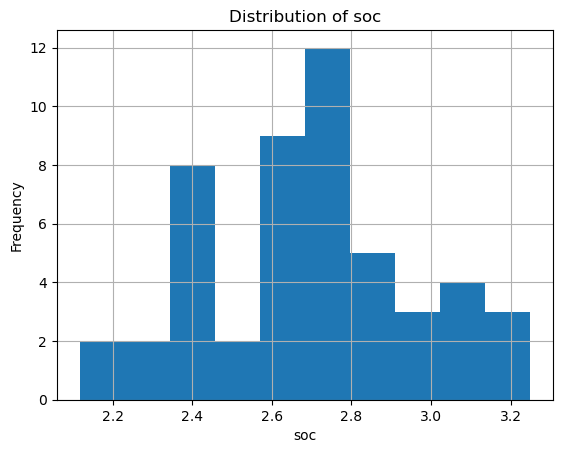

ph.h2o_unit [None]


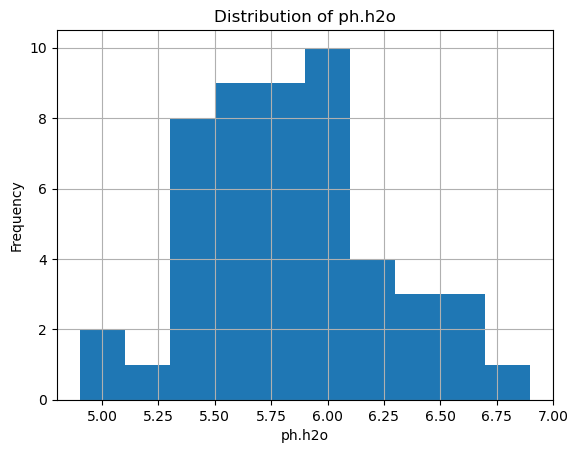

clay_unit ['%']


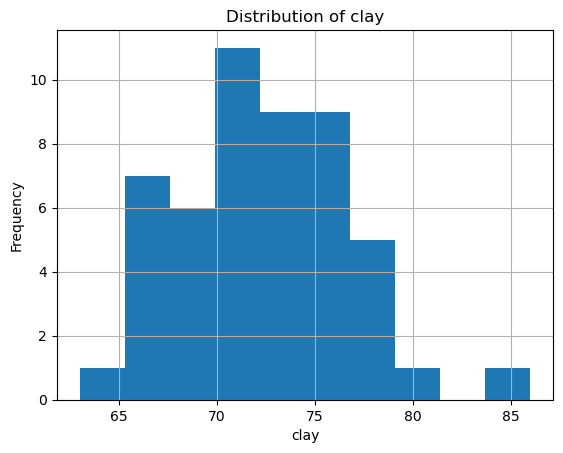

In [31]:
#| code-fold: true

import matplotlib.pyplot as plt

for prop in ['soc', 'ph.h2o', 'clay']:
    unit  = f"{prop}_unit"
    if unit in harmonized_df.columns:
        print(unit, harmonized_df[unit].unique())
    plt.figure()  # create a new figure for each property
    harmonized_df[prop].hist()
    plt.title(f'Distribution of {prop}')
    plt.xlabel(prop)
    plt.ylabel('Frequency')
    plt.show()

In our case, each property is recorded using a single unit, and the distributions show no unrealistic values.  
Therefore, no additional processing is required. We remove all unit and method columns and save the final harmonized dataset as `all_harmonized_{version_code}.pq`, which includes:
  - Metadata  
  - Property information  
  - Harmonized values  

This dataset is ready for spatial overlay and modeling.


In [32]:
#| code-fold: true

harmonize_folder = f'{parent_path}/data_harmonized'
harmonized_df.to_parquet(f'{harmonize_folder}/all_harmonized_{version}.pq')
harmonized_df

,lon,lat,dataset_id,subset_id,country,hzn_dep,soc_unit,clay_unit,year,soc_som,...,extractable.k_method,carbonates_unit,carbonates_method,cf.vol,cf.vol_unit,cf.vol_method,anonymized,soc,ph.h2o,clay
0,-50.570452,-27.342563,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.8717,5.8,68.0
1,-50.570453,-27.343003,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.9471,5.9,68.0
2,-50.570818,-27.343238,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.7209,5.6,66.0
3,-50.570816,-27.342786,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.7963,5.4,76.0
4,-50.570804,-27.342325,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.5701,5.9,68.0
5,-50.571298,-27.342560,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.5701,5.8,71.0
6,-50.571314,-27.342993,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.7963,5.5,76.0
7,-50.571310,-27.343448,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,3.2500,5.6,71.0
8,-50.571783,-27.343668,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,2.8717,5.7,66.0
9,-50.571795,-27.343202,LimeSoDa,SC.50,Brazil,10.0,%,%,2013.0,NaN,...,None,None,None,NaN,None,None,NaN,3.1746,5.8,68.0
